In [66]:
#1 Install necessary libraries
%pip install shap matplotlib
#%pip install ipympl #you can install this to interact with the created graphs (zoom, move axes around)

Note: you may need to restart the kernel to use updated packages.


<Figure size 640x480 with 0 Axes>

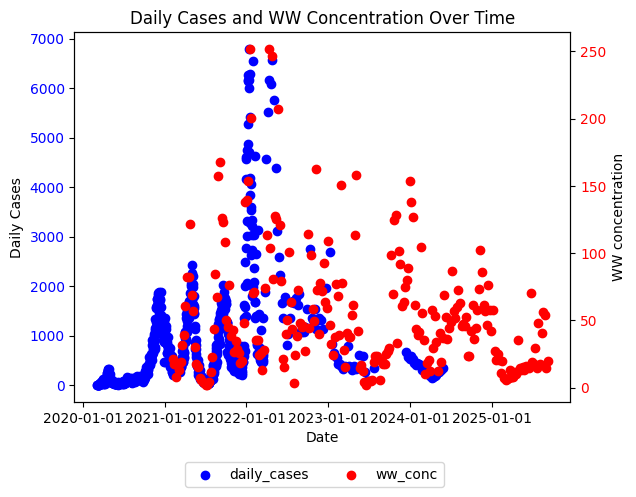

In [90]:
#2 Import the datafiles and modify

import pandas as pd # data processing with CSV files
import numpy as np # linear algebra computations
import matplotlib.pyplot as plt # plotting graphs
import matplotlib.dates as mdates
#%matplotlib widget #you can use this to interact with the created graphs (zoom, move axes around)

# Loading in data CSV files 
df_past_data = pd.read_csv(r'C:\Users\quin4\OneDrive\Documents\UofC_Masters\ENGG680_python\Project Files\New_data_for_code\aligned_past_data_2020to2024_infection_deaths.csv')
df_past_ww = pd.read_csv(r'C:\Users\quin4\OneDrive\Documents\UofC_Masters\ENGG680_python\Project Files\New_data_for_code\wastewater_only_covid_AB.csv')

# Modifying dataframes (dropping uncessesary columns) 
df_past_data['date'] = pd.to_datetime(df_past_data['date'], format='%Y-%m-%d') 
df_past_data = df_past_data.drop(['year', 'total_tests', 'total_recoveries', 'total_vaccines_distributed'], axis=1)
df_past_data = df_past_data.rename(columns = {'total_fatalities': 'total_deaths', 'total_criticals': 'total_ICU'})

df_past_ww = df_past_ww.rename(columns={'weekstart': 'date', 'w_avg': 'ww_concentration'})
df_past_ww['date'] = pd.to_datetime(df_past_ww['date'], format='%Y-%m-%d')
df_past_ww = df_past_ww.drop(['Location', 'EpiWeek', 'site', 'city', 'province', 'country', 'EpiYear','measureid', 'min', 'max', 'pruid', 'populationcoverage'], axis=1)

# Making the historical data show the daily case counts instead of the cumulative counts
exclude_column = 'date'
columns_to_diff = df_past_data.columns.difference([exclude_column])
df_past_data[columns_to_diff] = df_past_data[columns_to_diff].diff()
df_past_data = df_past_data.rename(columns = {'total_cases': 'daily_cases', 'total_deaths': 'daily_deaths', 'total_hospitalizations': 'daily_hospitalizations', 'total_ICU': 'daily_ICU', 'total_vaccinations': 'daily_vaccinations', 'total_vaccinated': 'daily_vaccinated', 'total_boosters_1': 'daily_booster1', 'total_boosters_2': 'daily_booster2'})

# Replacing negative numbers and zeros with NaN
df_past_data.loc[df_past_data['daily_cases'] <= 0, 'daily_cases'] = np.nan
df_past_data.loc[df_past_data['daily_deaths'] <= 0, 'daily_deaths'] = np.nan
df_past_data.loc[df_past_data['daily_hospitalizations'] <= 0, 'daily_hospitalizations'] = np.nan
df_past_data.loc[df_past_data['daily_ICU'] <= 0, 'daily_ICU'] = np.nan
df_past_data.loc[df_past_data['daily_vaccinations'] <= 0, 'daily_vaccinations'] = np.nan
df_past_data.loc[df_past_data['daily_vaccinated'] <= 0, 'daily_vaccinated'] = np.nan
df_past_data.loc[df_past_data['daily_booster1'] <= 0, 'daily_booster1'] = np.nan
df_past_data.loc[df_past_data['daily_booster2'] <= 0, 'daily_booster2'] = np.nan

# Drop empty rows for both dataframes
df_past_data = df_past_data.dropna(how='all')
df_past_ww = df_past_ww.dropna(how='all')

# Merging past data and wastwater datasets (they do not have the same dates) with outer merge
df_merged_data = pd.merge(df_past_data, df_past_ww, on='date', how='outer')

# Sort the dataframe by date (just to make sure)
df_merged_data = df_merged_data.sort_values(by='date').reset_index(drop=True)

# Date formatter for plotting 
date_form = mdates.DateFormatter('%Y-%m-%d')

# Graphing initial dataset
fig = plt.figure()
fig, ax1 = plt.subplots()
ax1.xaxis.set_major_formatter(date_form)
ax1.scatter(df_merged_data['date'], df_merged_data['daily_cases'], label = 'daily_cases', color = 'blue')
ax1.set_xlabel('Date')
ax1.set_ylabel('Daily Cases')
ax1.tick_params(axis='y', labelcolor='blue')
ax2 = ax1.twinx()

ax2.scatter(df_merged_data['date'], df_merged_data['ww_concentration'], label = 'ww_conc', color = 'red')
ax2.set_ylabel('WW concentration')
ax2.tick_params(axis='y', labelcolor='red')
plt.title('Daily Cases and WW Concentration Over Time')
fig.legend(bbox_to_anchor=(0.5, -0.0005), loc='upper center', ncol=2) #place the legend below the chart
plt.show()



In [91]:
#3 Choose consistent dates for the historical data
"""
Run this only once, if you need to run again must re-run previous cell!
"""
# ww start 2021-02-07, each week, end 2025-09-07
# data start 2020-01-25, per day(ish), end 2023-07-26
starting_date = '2021-02-07'
ending_date = '2022-03-07'

# Find the integer location for the common start date and crop the dataframe
start_date = df_merged_data.index[df_merged_data['date'] == starting_date].tolist()
start = start_date[0]
df_merged_data = df_merged_data.iloc[start:]
df_merged_data = df_merged_data.sort_values(by='date').reset_index(drop=True)

# Find the integer location for the common end date and crop the dataframe 
end_date = df_merged_data.index[df_merged_data['date'] == ending_date].tolist()
end = end_date[0]
df_merged_data = df_merged_data.iloc[:end]
df_merged_data = df_merged_data.sort_values(by='date').reset_index(drop=True)
print(df_merged_data['date'].head(1))
print(df_merged_data['date'].tail(1))


0   2021-02-07
Name: date, dtype: datetime64[ns]
392   2022-03-06
Name: date, dtype: datetime64[ns]


<Figure size 640x480 with 0 Axes>

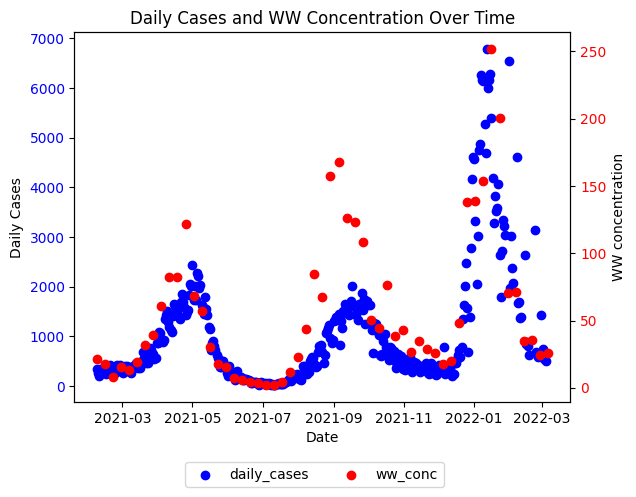

In [92]:
#4 Plot the Shortened Dataset

# Date formatter for plotting 
date_form = mdates.DateFormatter('%Y-%m')

fig2 = plt.figure()
fig2, ax3 = plt.subplots()
ax3.xaxis.set_major_formatter(date_form)
ax3.scatter(df_merged_data['date'], df_merged_data['daily_cases'], label = 'daily_cases', color = 'blue')
ax3.set_xlabel('Date')
ax3.set_ylabel('Daily Cases')
ax3.tick_params(axis='y', labelcolor='blue')
ax4 = ax3.twinx()

ax4.scatter(df_merged_data['date'], df_merged_data['ww_concentration'], label = 'ww_conc', color = 'red')
ax4.set_ylabel('WW concentration')
ax4.tick_params(axis='y', labelcolor='red')
plt.title('Daily Cases and WW Concentration Over Time')
fig2.legend(bbox_to_anchor=(0.5, -0.0005), loc='upper center', ncol=2) #place the legend below the chart
plt.show()

In [93]:
#5 resample and interpolate the data to a consistent timeseries
df_merged_data = df_merged_data.set_index('date')
df_resampled_data_D = df_merged_data.resample('D')
df_interpolated_data = df_resampled_data_D.interpolate(method='linear')
print(df_interpolated_data.dtypes)

daily_cases               float64
daily_deaths              float64
daily_hospitalizations    float64
daily_ICU                 float64
daily_vaccinations        float64
daily_vaccinated          float64
daily_booster1            float64
daily_booster2            float64
ww_concentration          float64
dtype: object


<Figure size 640x480 with 0 Axes>

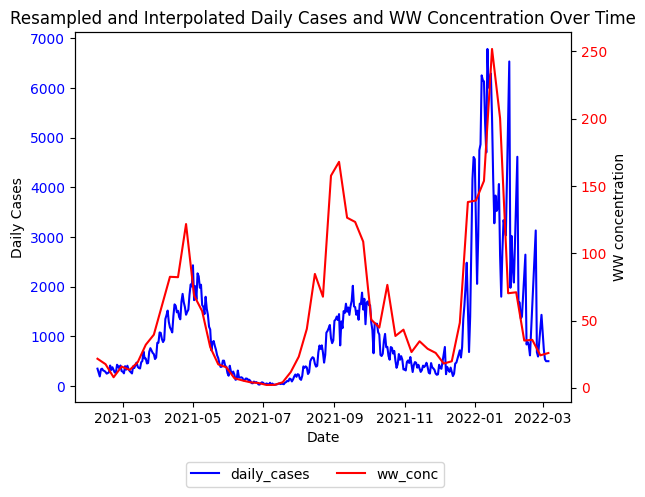

In [94]:
#6 Plot the interpolated data
# Date formatter for plotting 
date_form = mdates.DateFormatter('%Y-%m')

fig3 = plt.figure()
fig3, ax5 = plt.subplots()
ax5.xaxis.set_major_formatter(date_form)
ax5.plot(df_interpolated_data.index, df_interpolated_data['daily_cases'], label = 'daily_cases', color = 'blue')
ax5.set_xlabel('Date')
ax5.set_ylabel('Daily Cases')
ax5.tick_params(axis='y', labelcolor='blue')
ax6 = ax5.twinx()

ax6.plot(df_interpolated_data.index, df_interpolated_data['ww_concentration'], label = 'ww_conc', color = 'red')
ax6.set_ylabel('WW concentration')
ax6.tick_params(axis='y', labelcolor='red')
plt.title('Resampled and Interpolated Daily Cases and WW Concentration Over Time')
fig3.legend(bbox_to_anchor=(0.5, -0.0005), loc='upper center', ncol=2) #place the legend below the chart
plt.show()


<Figure size 640x480 with 0 Axes>

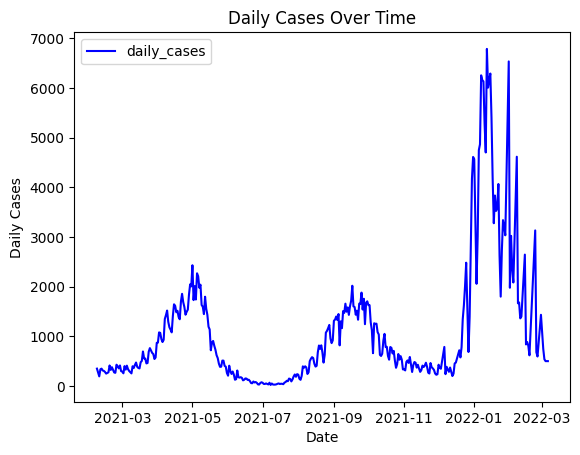

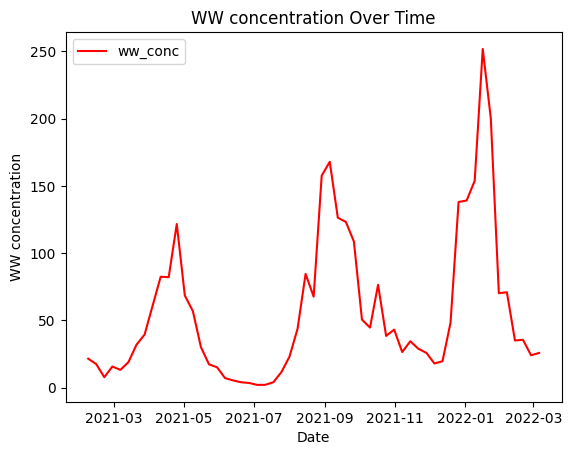

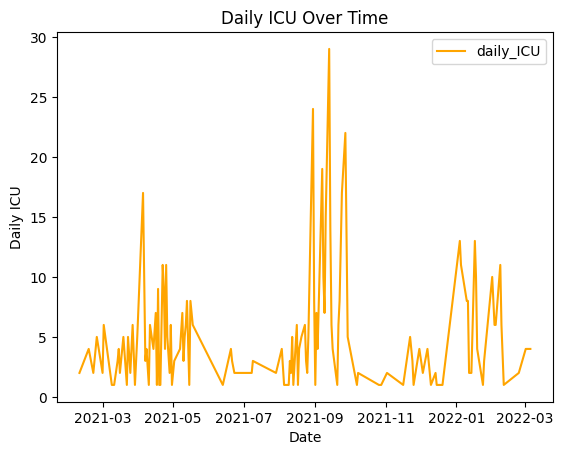

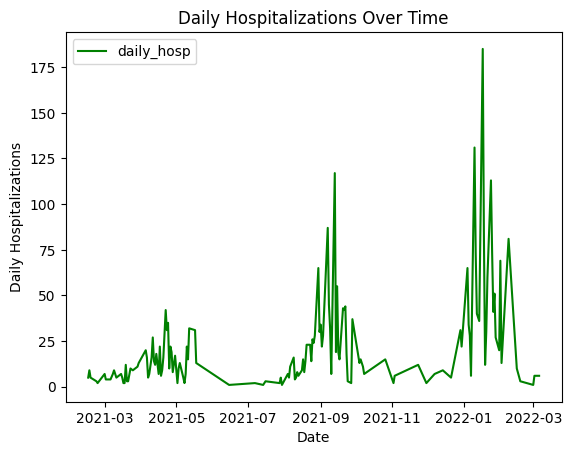

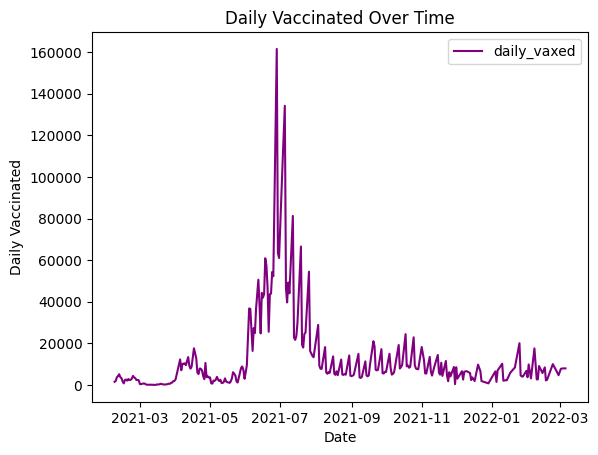

In [95]:
#7 Plot all data to check
# Date formatter for plotting 
date_form = mdates.DateFormatter('%Y-%m')

fig4 = plt.figure()
fig4, ax7 = plt.subplots()
ax7.xaxis.set_major_formatter(date_form)
ax7.plot(df_interpolated_data.index, df_interpolated_data['daily_cases'], label = 'daily_cases', color = 'blue')
ax7.set_xlabel('Date')
ax7.set_ylabel('Daily Cases')
ax7.set_title('Daily Cases Over Time')
ax7.legend()

fig4, ax8 = plt.subplots()
ax8.xaxis.set_major_formatter(date_form)
ax8.plot(df_interpolated_data.index, df_interpolated_data['ww_concentration'], label = 'ww_conc', color = 'red')
ax8.set_xlabel('Date')
ax8.set_ylabel('WW concentration')
ax8.set_title('WW concentration Over Time')
ax8.legend()

fig4, ax9 = plt.subplots()
ax9.xaxis.set_major_formatter(date_form)
ax9.plot(df_interpolated_data.index, df_interpolated_data['daily_ICU'], label = 'daily_ICU', color = 'orange')
ax9.set_xlabel('Date')
ax9.set_ylabel('Daily ICU')
ax9.set_title('Daily ICU Over Time')
ax9.legend()

fig4, ax10 = plt.subplots()
ax10.xaxis.set_major_formatter(date_form)
ax10.plot(df_interpolated_data.index, df_interpolated_data['daily_hospitalizations'], label = 'daily_hosp', color = 'green')
ax10.set_xlabel('Date')
ax10.set_ylabel('Daily Hospitalizations')
ax10.set_title('Daily Hospitalizations Over Time')
ax10.legend()

fig4, ax11 = plt.subplots()
ax11.xaxis.set_major_formatter(date_form)
ax11.plot(df_interpolated_data.index, df_interpolated_data['daily_vaccinated'], label = 'daily_vaxed', color = 'purple')
ax11.set_xlabel('Date')
ax11.set_ylabel('Daily Vaccinated')
ax11.set_title('Daily Vaccinated Over Time')
ax11.legend()

plt.show()

--- Starting ICU Demand and Cost Forecasting Project ---
Historical Data Loaded (Total Rows: 391)
Total Features Used: 23

--- Training Model 1: ICU Load Forecast ---
--- Training Model 2: Operational Cost Estimation ---


Evaluation for Predicted ICU Load (Patients):
  R-squared (R²): -1.7820
  Mean Absolute Error (MAE): 4.42
  Root Mean Squared Error (RMSE): 5.50

Evaluation for Predicted Operational Cost (CAD):
  R-squared (R²): -1.6358
  Mean Absolute Error (MAE): 167,049.62
  Root Mean Squared Error (RMSE): 207,933.61


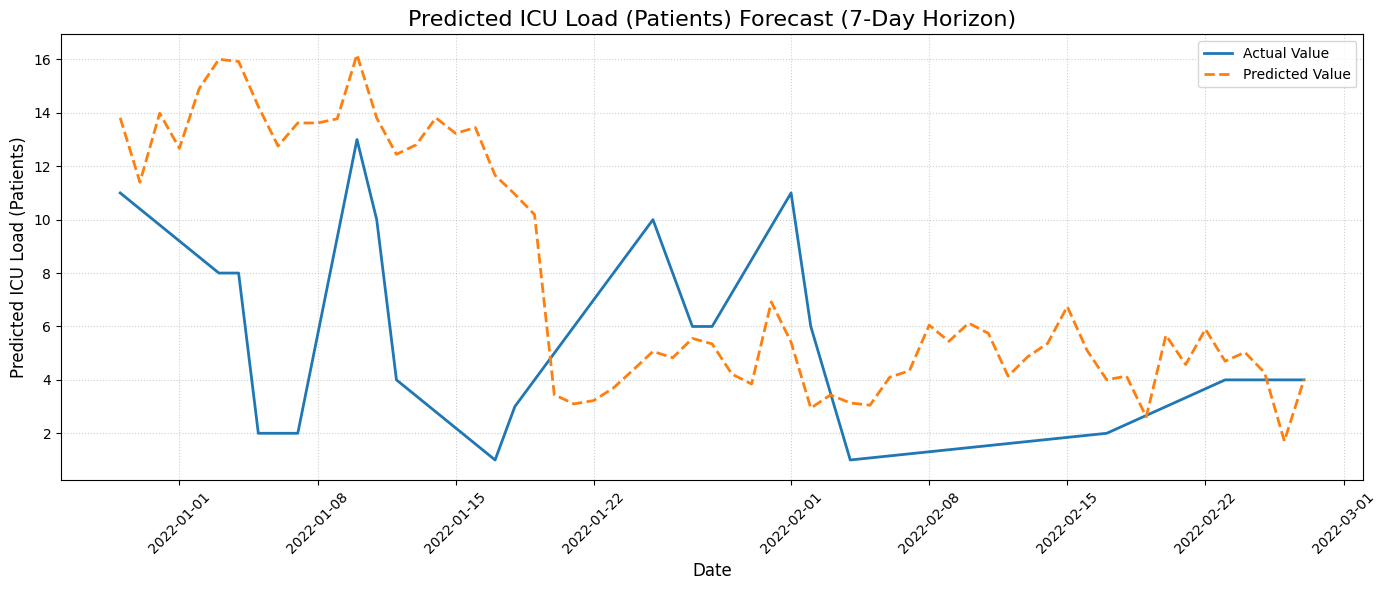

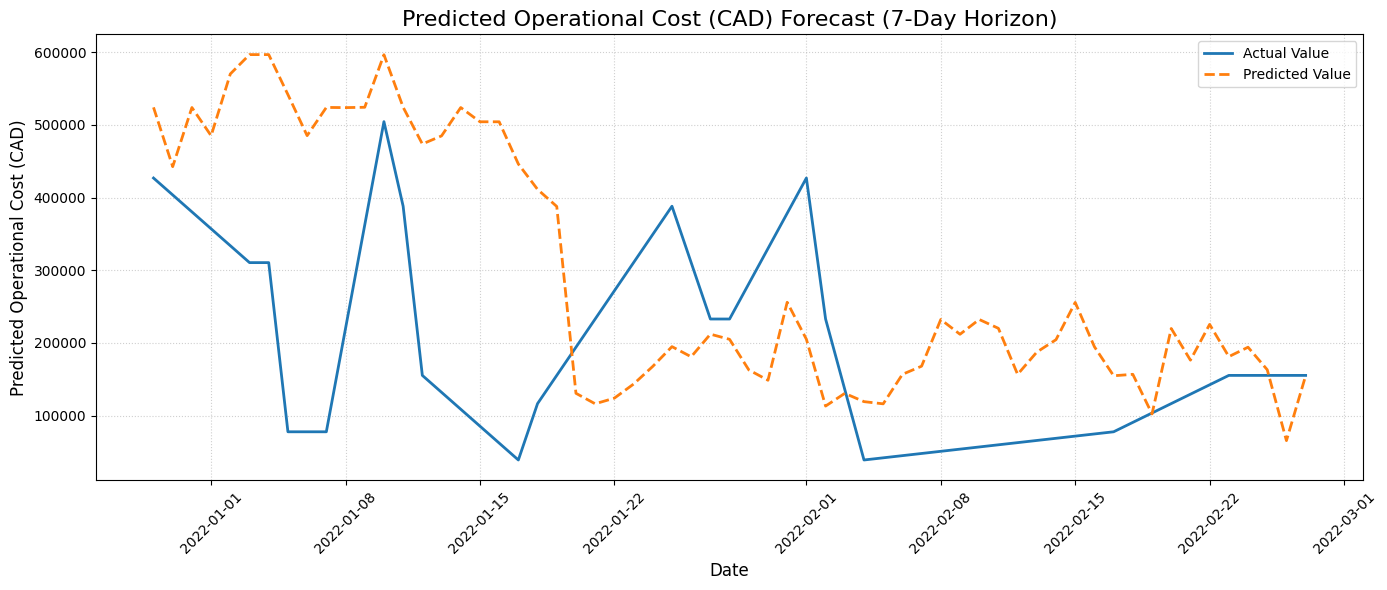

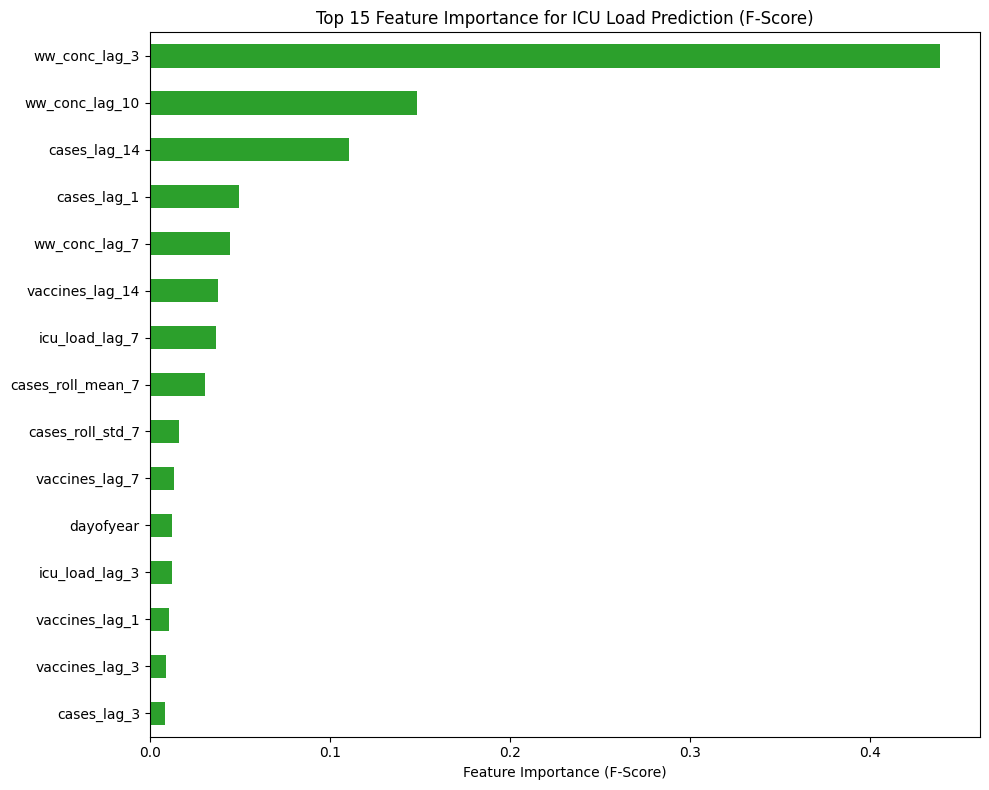


--- Generating SHAP Explanation ---


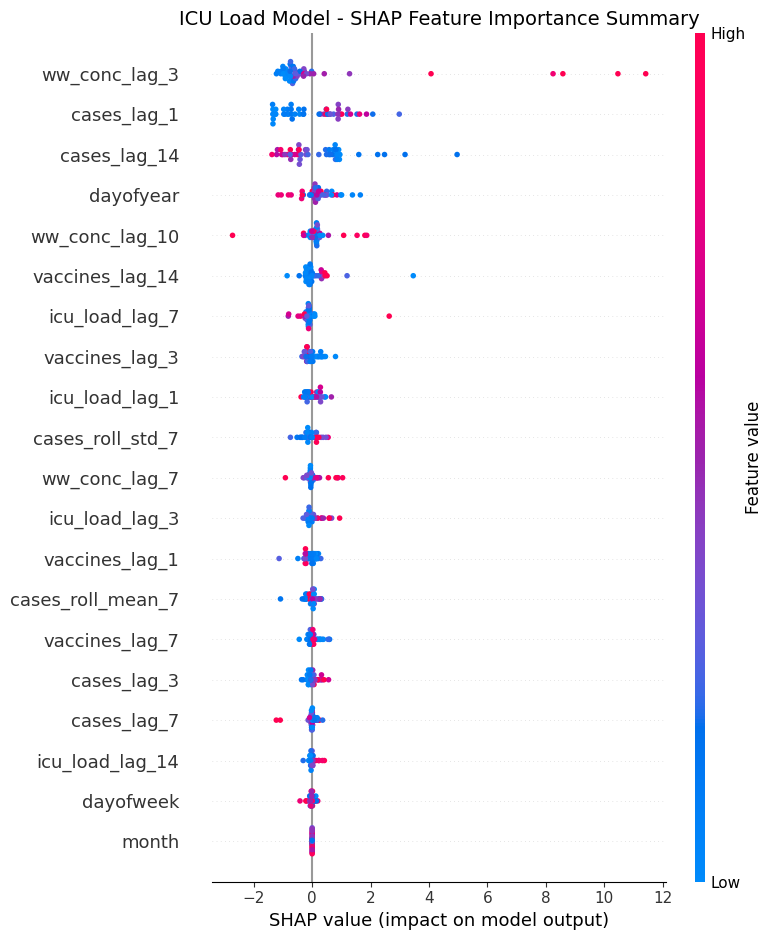


--- Starting Robust Iterative 30-Day Forecast ---
Robust Iterative Forecast Complete.

30-Day Iterative Forecast Results (First 5 Days):
            Predicted ICU Load
2022-03-13                   2
2022-03-14                   2
2022-03-15                   2
2022-03-16                   2
2022-03-17                   2

Pipeline Execution Complete. Check plots for results and feature importance.


In [99]:
import pandas as pd # data processing with CSV files
import numpy as np # linear algebra computations
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
import matplotlib.pyplot as plt
import shap

# --- 0. Configuration and Data Setup ---
# Define the prediction horizon (L days ahead)
PREDICTION_HORIZON_DAYS = 7 
# Define the Cost Proxy factors (BASED ON CIHI DATA - Cost estimates .csv)
# CIHI data shows Avg ICU cost is ~35,125 CAD over 13.5 days.
# We set a base admission cost and a daily operational cost reflecting this.
COST_PER_ADMISSION = 36384  # Data-informed cost for confirmed and suspected covid diagnosis testing. Based on CIHI data from 2023-2024
COST_PER_PATIENT_DAY_ICU = 2432.68  # Data-informed cost for daily operational cost. Based on CIHI data from 2023-2024 (Average cost of hosptitalization with ICU / average length of stay in days =$82711 / 34 days)
EMMERGENCY_ICU_CAPACITY = 450  # Data-informed emmergency ICU capacity for Alberta, from Alberta Health Services
NORMAL_IUC_CAPACITY = 393 # Data-informed current ICU capacity for Alberta, from Alberta Health Services

def create_historical_data():
    """
    Creates a time-series DataFrame representing historical daily Covid data for Alberta Dec 2020 - June 2024
    """
    df = pd.DataFrame()
    # Core Features
    df['new_cases'] = df_interpolated_data['daily_cases']
    df['wastewater_conc'] = df_interpolated_data['ww_concentration']
    df['icu_admissions'] = df_interpolated_data['daily_ICU']
    df['vaccinations'] = df_interpolated_data['daily_vaccinated']

    # Target 1 (ICU Load)
    df['icu_load'] = df['icu_admissions']

    # Target 2 (Operational Cost - The Proxy Variable, now using better factors)
    df['operational_cost'] = (df['icu_admissions'] * COST_PER_ADMISSION) + \
                             (df['icu_load'] * COST_PER_PATIENT_DAY_ICU)
    
    
    # Simulate a policy change
    df.loc[df.index > '2023-01-01', 'policy_level'] = 1
    df.loc[df.index <= '2023-01-01', 'policy_level'] = 0
    return df.dropna().astype({'policy_level': int})

# --- 1. Data Loading and Feature Engineering ---

def create_features(df, look_ahead):
    """
    Generates all time-series features (Lags, Rolling Averages, Calendar)
    and defines the target variable shifted by 'look_ahead' days.
    """
    # --- A. Calendar Features (for Seasonality) ---
    df['dayofweek'] = df.index.dayofweek
    df['dayofyear'] = df.index.dayofyear
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['is_weekend'] = df.index.dayofweek.isin([5, 6]).astype(int)

    # --- B. Lag Features (Crucial for Time Series) ---
    for lag in [1, 3, 7, 14]:
        df[f'icu_load_lag_{lag}'] = df['icu_load'].shift(lag)
        df[f'cases_lag_{lag}'] = df['new_cases'].shift(lag)
        df[f'vaccines_lag_{lag}'] = df['vaccinations'].shift(lag)

    # Wastewater is a LEADING indicator, so use smaller, leading lags
    for lag in [3, 7, 10]:
        df[f'ww_conc_lag_{lag}'] = df['wastewater_conc'].shift(lag)

    # --- C. Rolling Window Features (for Trend and Noise Reduction) ---
    df['cases_roll_mean_7'] = df['new_cases'].rolling(window=7).mean()
    df['cases_roll_std_7'] = df['new_cases'].rolling(window=7).std()

    # --- D. Define Target (Shifted for Prediction) ---
    # Target Y1: ICU Load L days in the future
    df['ICU_Load_Target'] = df['icu_load'].shift(-look_ahead)

    # Target Y2: Operational Cost L days in the future
    df['Cost_Target'] = df['operational_cost'].shift(-look_ahead)

    df = df.dropna()
    return df

# --- Function for Hyperparameter Tuning (Unchanged) ---
def tune_model_with_random_search(X_train, Y_train):
    """
    Uses RandomizedSearchCV to find optimal hyperparameters for XGBoost.
    """
    print("\n--- Starting Hyperparameter Tuning (Random Search) ---")

    param_grid = {
        'n_estimators': [100, 500, 1000],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [4, 6, 8, 10],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0]
    }

    xgb = XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)
    tscv_search = TimeSeriesSplit(n_splits=3)

    random_search = RandomizedSearchCV(
        estimator=xgb,
        param_distributions=param_grid,
        n_iter=10,
        scoring='neg_mean_squared_error',
        cv=tscv_search,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )

    random_search.fit(X_train, Y_train)

    print(f"Best parameters found: {random_search.best_params_}")

    best_model = XGBRegressor(**random_search.best_params_, objective='reg:squarederror', random_state=42, n_jobs=-1)
    return best_model

# --- 2. Chained Model Pipeline Functions (FIXED) ---

def train_chained_pipeline(df_processed, features, target_y1, target_y2, perform_tuning=False):
    """
    Trains Model 1 (ICU Load) and Model 2 (Cost) using a TimeSeriesSplit.
    """

    # Use TimeSeriesSplit for validation
    tscv = TimeSeriesSplit(n_splits=5)
    train_index, test_index = list(tscv.split(df_processed))[4]

    X_train, X_test = df_processed.iloc[train_index][features], df_processed.iloc[test_index][features]
    Y1_train, Y1_test = df_processed.iloc[train_index][target_y1], df_processed.iloc[test_index][target_y1]
    # Keep raw cost targets for Model 2 evaluation
    Y2_train_raw, Y2_test_raw = df_processed.iloc[train_index][target_y2], df_processed.iloc[test_index][target_y2]

    # --- Scaling ---
    scaler = MinMaxScaler() # Feature scaler
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)
    X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=features, index=X_test.index)

    # Initialize and fit a separate scaler for the COST TARGET (Y2)
    cost_scaler = MinMaxScaler()
    # Reshape training data for scaler compatibility and fit
    Y2_train_scaled = cost_scaler.fit_transform(Y2_train_raw.values.reshape(-1, 1)).flatten()
    # Y2_test_raw remains unscaled for accurate evaluation metrics


    # --- Model 1: ICU Load Forecasting (Y1) ---
    print("\n--- Training Model 1: ICU Load Forecast ---")

    if perform_tuning:
        model_icu = tune_model_with_random_search(X_train_scaled_df, Y1_train)
        model_icu.fit(X_train_scaled_df, Y1_train)
    else:
        model_icu = XGBRegressor(
            objective='reg:squarederror',
            n_estimators=1000,
            learning_rate=0.05,
            max_depth=6,
            random_state=42,
            n_jobs=-1
        )
        model_icu.fit(X_train_scaled_df, Y1_train)

    Y1_pred = model_icu.predict(X_test_scaled_df)

    # --- Model 2: Operational Cost Estimation (Y2) ---
    print("--- Training Model 2: Operational Cost Estimation ---")

    # Features for Model 2 training: Original features + ACTUAL ICU Load (Y1_train)
    features_m2_train = X_train_scaled_df.copy()
    features_m2_train['predicted_icu_load'] = Y1_train

    # Use slightly simplified parameters for Model 2 as the task is relatively less complex
    model_cost = XGBRegressor(
        objective='reg:squarederror',
        n_estimators=300,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        n_jobs=-1
    )
    # Train Model 2 on the SCALED COST TARGET
    model_cost.fit(features_m2_train, Y2_train_scaled)

    # --- Final Chained Prediction for Cost ---
    # Features for Model 2 testing: Original features + PREDICTED ICU Load (Y1_pred)
    features_m2_test = X_test_scaled_df.copy()
    features_m2_test['predicted_icu_load'] = Y1_pred

    # Predict the SCALED cost
    Y2_pred_scaled = model_cost.predict(features_m2_test)

    # Inverse transform the prediction back to the original CAD value for evaluation
    Y2_pred = cost_scaler.inverse_transform(Y2_pred_scaled.reshape(-1, 1)).flatten()

    # Return the raw (unscaled) test targets for evaluation
    return Y1_pred, Y1_test, Y2_pred, Y2_test_raw, model_icu, scaler

# --- Function for Iterative Long-Range Forecast (Unchanged) ---
def iterative_forecast(model, scaler, df_raw_history, features, look_ahead, days_to_predict=30):
    """
    Performs an iterative, long-range forecast.
    """
    print(f"\n--- Starting Robust Iterative {days_to_predict}-Day Forecast ---")

    RAW_COLS = ['icu_load', 'new_cases', 'wastewater_conc', 'vaccinations','policy_level', 'icu_admissions', 'operational_cost']
    current_raw_df = df_raw_history[RAW_COLS].copy()

    last_date = current_raw_df.index[-1]
    future_forecasts = []

    for i in range(1, days_to_predict + 1):

        forecast_date = last_date + pd.Timedelta(days=i)

        new_raw_row = {
            'icu_load': 0,
            'new_cases': current_raw_df['new_cases'].iloc[-1],
            'wastewater_conc': current_raw_df['wastewater_conc'].iloc[-1],
            'icu_admissions': current_raw_df['icu_admissions'].iloc[-1],
            'vaccinations': current_raw_df['vaccinations'].iloc[-1],
            'policy_level': current_raw_df['policy_level'].iloc[-1],
            'operational_cost': 0,
        }

        if i > 1:
            new_raw_row['icu_load'] = future_forecasts[-1]
        else:
            new_raw_row['icu_load'] = current_raw_df['icu_load'].iloc[-1]


        temp_df = pd.DataFrame(new_raw_row, index=[forecast_date])
        current_raw_df = pd.concat([current_raw_df, temp_df])

        processed_temp = create_features(current_raw_df, look_ahead=0)

        X_predict_raw = processed_temp.iloc[[-1]][features]

        X_scaled = scaler.transform(X_predict_raw)

        Y_next = model.predict(X_scaled)[0]
        Y_next = np.maximum(0, Y_next).round().astype(int)

        future_forecasts.append(Y_next)

        current_raw_df.loc[forecast_date, 'icu_load'] = Y_next

    forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=look_ahead), periods=days_to_predict, freq='D')
    forecast_results = pd.DataFrame({
        'Predicted ICU Load': future_forecasts
    }, index=forecast_dates)

    print("Robust Iterative Forecast Complete.")
    return forecast_results


# --- 3. Evaluation and Visualization (Unchanged) ---

def evaluate_and_plot(Y_pred, Y_test, title):
    """Calculates metrics and plots Actual vs. Predicted."""

    mae = mean_absolute_error(Y_test, Y_pred)
    mse = mean_squared_error(Y_test, Y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(Y_test, Y_pred)

    print(f"\nEvaluation for {title}:")
    print(f"  R-squared (R²): {r2:.4f}")
    print(f"  Mean Absolute Error (MAE): {mae:,.2f}")
    print(f"  Root Mean Squared Error (RMSE): {rmse:,.2f}")

    # Plotting
    plt.figure(figsize=(14, 6))
    plt.plot(Y_test.index, Y_test.values, label='Actual Value', color='#1f77b4', linewidth=2)
    plt.plot(Y_test.index, Y_pred, label='Predicted Value', color='#ff7f0e', linestyle='--', linewidth=2)
    plt.title(f'{title} Forecast ({PREDICTION_HORIZON_DAYS}-Day Horizon)', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel(title, fontsize=12)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.xticks(rotation=45)
    plt.tight_layout()
    #  (This tag is contextual and helpful)

# --- Function for SHAP Visualization (Unchanged) ---
def plot_shap_summary(model, X_data, feature_names, title):
    """
    Calculates and plots SHAP values for model explainability.
    """
    print("\n--- Generating SHAP Explanation ---")

    explainer = shap.TreeExplainer(model)

    X_sample = X_data.sample(n=min(50, len(X_data)), random_state=42)
    shap_values = explainer.shap_values(X_sample.values)

    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        shap_values,
        X_sample,
        feature_names=feature_names,
        show=False,
        plot_type="dot"
    )
    plt.title(f'{title} - SHAP Feature Importance Summary', fontsize=14)
    plt.tight_layout()
    plt.show(block=False)
    #  (This tag is contextual and helpful)

# --- 4. Main Execution ---

if __name__ == '__main__':
    print("--- Starting ICU Demand and Cost Forecasting Project ---")

    # Step 1: Data Preparation
    data = create_historical_data()
    print(f"Historical Data Loaded (Total Rows: {len(data)})")

    # Step 2: Feature Engineering
    df_final = create_features(data.copy(), PREDICTION_HORIZON_DAYS)

    target_y1 = 'ICU_Load_Target'
    target_y2 = 'Cost_Target'

    EXCLUDE_COLS = ['new_cases', 'wastewater_conc', 'icu_admissions', 'vaccinations', 'icu_load',
                    'operational_cost', target_y1, target_y2]
    features = [col for col in df_final.columns if col not in EXCLUDE_COLS]
    print(f"Total Features Used: {len(features)}")

    # Step 3: Train Chained Pipeline (FIXED)
    Y1_pred, Y1_test, Y2_pred, Y2_test, model_icu, scaler = train_chained_pipeline(
        df_final, features, target_y1, target_y2, perform_tuning=False
    )

    # Step 4: Evaluation and Visualization
    print("\n========================================================")

    # Evaluate Model 1 (ICU Load)
    evaluate_and_plot(Y1_pred, Y1_test, 'Predicted ICU Load (Patients)')

    # Evaluate Model 2 (Operational Cost - NOW CORRECTLY SCALED)
    evaluate_and_plot(Y2_pred, Y2_test, 'Predicted Operational Cost (CAD)')

    # Feature Importance (Standard XGBoost)
    plt.figure(figsize=(10, 8))
    importance = pd.Series(model_icu.feature_importances_, index=features).sort_values(ascending=False).head(15)
    importance.plot(kind='barh', color='#2ca02c')
    plt.title('Top 15 Feature Importance for ICU Load Prediction (F-Score)')
    plt.xlabel('Feature Importance (F-Score)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show(block=False)
    #  (This tag is contextual and helpful)

    # SHAP Explanations
    X_full_scaled = scaler.transform(df_final[features])
    X_full_scaled_df = pd.DataFrame(X_full_scaled, columns=features, index=df_final.index)
    plot_shap_summary(model_icu, X_full_scaled_df, features, 'ICU Load Model')

    # Run the Iterative Forecast
    long_range_forecast = iterative_forecast(
        model_icu,
        scaler,
        data,
        features,
        PREDICTION_HORIZON_DAYS,
        days_to_predict=30
    )

    print("\n30-Day Iterative Forecast Results (First 5 Days):")
    print(long_range_forecast.head())

    plt.show()

    print("\n========================================================")
    print("Pipeline Execution Complete. Check plots for results and feature importance.")

